In [1]:
!nvidia-smi

Thu Dec 18 22:37:41 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.274.02             Driver Version: 535.274.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off | 00000000:00:10.0 Off |                    0 |
| N/A   34C    P0             175W / 250W |  20190MiB / 40960MiB |     21%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
import os

# Silence TensorFlow C++ logs
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warning, 3=error


#os.environ['CUDA_VISIBLE_DEVICES'] = os.environ.get('CUDA_VISIBLE_DEVICES', '')

In [3]:
#%%capture
import tensorflow as tf
#tf.get_logger().setLevel('ERROR')
from tensorflow.keras import mixed_precision
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
#cell_5
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import cohen_kappa_score, f1_score, recall_score, accuracy_score
#cell_6
from tensorflow.keras import layers, models, backend
#cell_7
from tensorflow.keras import callbacks
# --- LOGGING CONFIGURATION ---
# '0' = All logs (Default)
# '1' = Hide INFO messages
# '2' = Hide INFO & WARNINGS
# '3' = Hide everything including ERRORS 
 

# --- 1. Enable Mixed Precision (Turbo Mode for A100) ---
# Uses 16-bit math for speed, but keeps 32-bit for stability.
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# --- 2. Configure Memory Growth ---
# Good practice to prevent allocation errors.
gpus = tf.config.list_physical_devices('GPU')
gpu_name = "Unknown"
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        gpu_name = gpus[0].name
    except RuntimeError as e:
        print(e)

# --- VISIBLE OUTPUT ---
print("="*40)
print(f"System Setup Complete")
print(f"GPU Detected: {gpu_name}")
print(f"Compute Policy: {policy.name} (16-bit optimization enabled)")
print(f"TensorFlow Version: {tf.__version__}")
print("="*40)

2025-12-18 22:37:50.901335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-18 22:37:50.916241: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-18 22:37:50.920702: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-18 22:37:50.932419: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-18 22:37:51.679148: W tensorflow/compiler/tf2

System Setup Complete
GPU Detected: /physical_device:GPU:0
Compute Policy: mixed_float16 (16-bit optimization enabled)
TensorFlow Version: 2.17.0


I0000 00:00:1766093872.962892 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1766093873.005868 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1766093873.007115 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [4]:
# --- PATH SETUP ---
BASE_DIR = Path("dr-data_variantB_green_circle")

# --- HYPERPARAMETERS ---
IMG_SIZE = (512, 512)   # High Res for detecting Microaneurysms
BATCH_SIZE = 16         # Optimized for A100
EPOCHS = 50             # Max duration
LEARNING_RATE = 1e-4    # Stable rate for Deep Networks

# --- VISIBLE OUTPUT ---
print("="*40)
print(f"Configuration Loaded")
print(f"Data Folder: {BASE_DIR.resolve()}")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print("="*40)

Configuration Loaded
Data Folder: /home/ali.al-kelabi/dr-data_variantB_green_circle
Image Size: (512, 512)
Batch Size: 16
Learning Rate: 0.0001


Path found: dr-data_variantB_green_circle/train


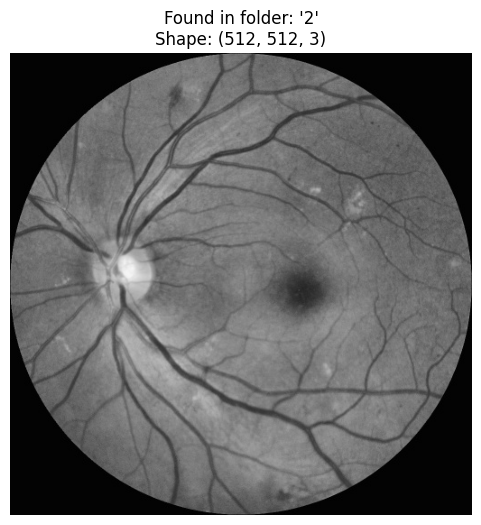

Image loaded successfully! Your data structure is correct.


In [5]:
train_path = BASE_DIR / "train"

# 1. Check if the path exists
if not train_path.exists():
    print(f"ERROR: The path {train_path} does not exist!")
else:
    print(f"Path found: {train_path}")
    
    # 2. Find class folders (0, 1, 2, 3, 4)
    # We filter specifically for folders, ignoring hidden files like .DS_Store
    classes = [d for d in os.listdir(train_path) if os.path.isdir(train_path / d)]
    
    if len(classes) > 0:
        # Pick the first class found (e.g., '0' - No DR)
        demo_class = classes[0]
        class_path = train_path / demo_class
        
        # Pick the first image in that folder
        images = os.listdir(class_path)
        if len(images) > 0:
            img_name = images[0]
            full_img_path = class_path / img_name
            
            # 3. Display the Image
            img = mpimg.imread(full_img_path)
            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.title(f"Found in folder: '{demo_class}'\nShape: {img.shape}")
            plt.axis('off')
            plt.show()
            print("Image loaded successfully! Your data structure is correct.")
        else:
            print(f"Class folder '{demo_class}' is empty.")
    else:
        print("No class folders (0, 1, 2...) found inside 'train'. Check directory structure.")

In [6]:
def process_data(image, label):
    # Normalize to 0-1
    image = tf.cast(image, tf.float32) / 255.0
    # Cast label to Float for Regression (e.g. 2 -> 2.0)
    label = tf.cast(label, tf.float32)
    return image, label

print("Scanning files...")

# 1. Train
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "train", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=True
)

# 2. Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "val", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False
)

# 3. Test
test_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "test", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False
)

# Optimize (Cache & Prefetch for speed)
train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# --- VISIBLE OUTPUT ---
print("="*40)
print(f"Data Pipeline Ready")
print(f"Training Batches: {len(train_ds)}")
print(f"Validation Batches: {len(val_ds)}")
print(f"Test Batches: {len(test_ds)}")
print("="*40)

Scanning files...
Found 64654 files belonging to 5 classes.


I0000 00:00:1766093885.423845 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1766093885.425376 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1766093885.426570 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1766093885.583793 1535288 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Found 13855 files belonging to 5 classes.
Found 13855 files belonging to 5 classes.
Data Pipeline Ready
Training Batches: 4041
Validation Batches: 866
Test Batches: 866


 Visualization Generated below.


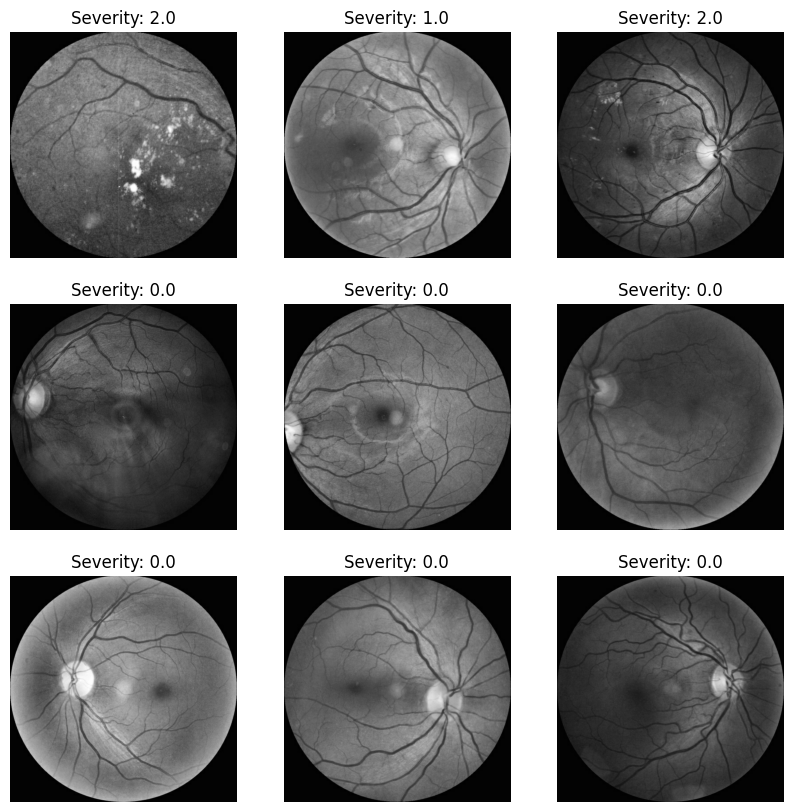

In [7]:
# Grab one batch
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Severity: {labels[i]:.1f}") # Shows 0.0, 1.0 etc
    plt.axis("off")

# --- VISIBLE OUTPUT ---
print(" Visualization Generated below.")
plt.show()

In [8]:
# --- 5. CUSTOM METRICS CALLBACK (RAM SAFE + F1 SCORE) ---
class MedicalMetrics(Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        
        print(f"\nCalculating metrics for epoch {epoch+1}...")

        y_true, y_pred = [], []

        # Loop through batches to stay RAM safe
        for x_batch, y_batch in self.val_ds:
            preds = self.model.predict(x_batch, verbose=0)
            
            # Convert continuous score -> class (0,1,2,3,4)
            preds = np.clip(np.round(preds).flatten(), 0, 4)

            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        
        # Calculate Metrics
        _kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
        _recall = recall_score(y_true, y_pred, average='macro')
        _f1 = f1_score(y_true, y_pred, average='macro')
        _acc = accuracy_score(y_true, y_pred)
        
        print(f" — val_kappa: {_kappa:.4f} — val_recall: {_recall:.4f} — val_f1: {_f1:.4f} — val_acc: {_acc:.4f}")
        
        # Add to history logs
        logs['val_kappa'] = _kappa
        logs['val_recall'] = _recall
        logs['val_f1'] = _f1
        logs['val_acc'] = _acc

metrics_callback = MedicalMetrics(val_ds)

# --- VISIBLE OUTPUT ---
print(" Custom Metrics Callback initialized.")
print("   It will print Kappa/Recall/F1/Accuracy after every training epoch.")

 Custom Metrics Callback initialized.
   It will print Kappa/Recall/F1/Accuracy after every training epoch.


In [9]:
def conv_block(x, growth_rate, name):
    """Standard DenseNet Composite Function: BN -> ReLU -> Conv"""
    # 1. Bottleneck (1x1 Conv)
    x1 = layers.BatchNormalization(name=name+'_0_bn')(x)
    x1 = layers.Activation('relu', name=name+'_0_relu')(x1)
    x1 = layers.Conv2D(4 * growth_rate, 1, use_bias=False, name=name+'_1_conv', kernel_initializer='he_normal')(x1)
    
    # 2. Main Conv (3x3)
    x1 = layers.BatchNormalization(name=name+'_1_bn')(x1)
    x1 = layers.Activation('relu', name=name+'_1_relu')(x1)
    x1 = layers.Conv2D(growth_rate, 3, padding='same', use_bias=False, name=name+'_2_conv', kernel_initializer='he_normal')(x1)
    
    # 3. Concatenate
    x = layers.Concatenate(name=name+'_concat')([x, x1])
    return x

def dense_block(x, blocks, name):
    for i in range(blocks):
        x = conv_block(x, 32, name=name+'_block' + str(i + 1))
    return x

def transition_layer(x, reduction, name):
    x = layers.BatchNormalization(name=name+'_bn')(x)
    x = layers.Activation('relu', name=name+'_relu')(x)
    filter_num = int(backend.int_shape(x)[-1] * reduction)
    x = layers.Conv2D(filter_num, 1, use_bias=False, name=name+'_conv', kernel_initializer='he_normal')(x)
    x = layers.AveragePooling2D(2, strides=2, name=name+'_pool')(x)
    return x

def build_densenet121(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Augmentation
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    # Stem (Fixed Naming here: removed '/')
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, padding='same', name='conv1_conv', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization(name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)
    
    # Dense Blocks
    x = dense_block(x, 6, name='conv2')
    x = transition_layer(x, 0.5, name='pool2')
    x = dense_block(x, 12, name='conv3')
    x = transition_layer(x, 0.5, name='pool3')
    x = dense_block(x, 24, name='conv4')
    x = transition_layer(x, 0.5, name='pool4')
    x = dense_block(x, 16, name='conv5')
    
    # Head
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.Dropout(0.5)(x) 
    
    # OUTPUT: Float32 required for Mixed Precision stability
    outputs = layers.Dense(1, activation='linear', dtype='float32', name='severity_score')(x)
    
    return models.Model(inputs, outputs, name='DenseNet121_Custom')

# Build
model = build_densenet121((IMG_SIZE[0], IMG_SIZE[1], 3))

# --- VISIBLE OUTPUT ---
print("DenseNet-121 Model Built Successfully.")
print(f"   Parameters: {model.count_params():,}")

DenseNet-121 Model Built Successfully.
   Parameters: 7,034,433


In [10]:
# 1. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',     # The Regression Trick
    metrics=['mae'] # Monitor Mean Absolute Error
)

# 2. Callbacks
my_callbacks = [
    callbacks.ModelCheckpoint('best_densenet_a100.keras', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    metrics_callback # Our custom metrics
]

# --- VISIBLE OUTPUT ---
print("Model Compiled.")
print("Optimizer: Adam")
print("Loss: Mean Squared Error (MSE)")
print("Callbacks: Checkpoint, EarlyStopping, ReduceLROnPlateau, CustomMetrics")

Model Compiled.
Optimizer: Adam
Loss: Mean Squared Error (MSE)
Callbacks: Checkpoint, EarlyStopping, ReduceLROnPlateau, CustomMetrics


In [ ]:
print(f"Starting Training on A100...")
print("   (This will take time.)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=my_callbacks
)

# --- VISIBLE OUTPUT ---
print("\nTraining Complete.")

In [9]:
print("RESUMING TRAINING (Safe Mode)...")

# 1. Load the Saved Model (Restores weights from Epoch ~12)
try:
    model = models.load_model('best_densenet_a100.keras')
    print("Successfully loaded 'best_densenet_a100.keras'")
except:
    print("Error: Could not find the file. Did you save it?")

# 2. Re-compile (Essential after loading to reset optimizer)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='mse',
    metrics=['mae']
)

# 3. Re-define Callbacks
my_callbacks = [
    callbacks.ModelCheckpoint('best_densenet_a100.keras', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    metrics_callback # <--- This requires Cell 5 to be run first!
]

# 4. Run for remaining epochs (Target is 50, you did ~13, so 37 left)
print("Resuming Training with Batch Size 19...")
history_continued = model.fit(
    train_ds,           # Uses the new Batch Size 16 (Safe!)
    validation_data=val_ds,
    epochs=10,          # Finishing the job
    callbacks=my_callbacks
)

RESUMING TRAINING (Safe Mode)...
Successfully loaded 'best_densenet_a100.keras'
Resuming Training with Batch Size 16...
Epoch 1/10


2025-12-18 22:39:33.165753: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1766093973.229679 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.373046 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.374434 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.377647 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.386398 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.389615 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.391694 1535564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766093973.393842 1535564 gpu_t

4040/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.3857 - mae: 0.3828

W0000 00:00:1766095415.998085 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095415.999451 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.000697 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.002564 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.005413 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.007180 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.009063 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.011072 1535561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1766095416.013011 1535561 gp

4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.3857 - mae: 0.3828

...

4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - loss: 0.3827 - mae: 0.3816
Calculating metrics for epoch 3...
 — val_kappa: 0.6977 — val_recall: 0.4038 — val_f1: 0.3989 — val_acc: 0.7397
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 2036s 504ms/step - loss: 0.3820 - mae: 0.3809 - val_loss: 0.4444 - val_mae: 0.3832 - learning_rate: 5.0000e-05 - val_kappa: 0.6977 - val_recall: 0.4038 - val_f1: 0.3989 - val_acc: 0.7397
Epoch 4/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - loss: 0.3808 - mae: 0.3784
Calculating metrics for epoch 4...
 — val_kappa: 0.7304 — val_recall: 0.4476 — val_f1: 0.4229 — val_acc: 0.7368
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1907s 472ms/step - loss: 0.3817 - mae: 0.3794 - val_loss: 0.4255 - val_mae: 0.4024 - learning_rate: 5.0000e-05 - val_kappa: 0.7304 - val_recall: 0.4476 - val_f1: 0.4229 - val_acc: 0.7368
Epoch 5/10


2025-12-19 00:38:34.478003: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - loss: 0.3802 - mae: 0.3785
Calculating metrics for epoch 5...
 — val_kappa: 0.6710 — val_recall: 0.3856 — val_f1: 0.3871 — val_acc: 0.7534
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1474s 365ms/step - loss: 0.3793 - mae: 0.3789 - val_loss: 0.4738 - val_mae: 0.3951 - learning_rate: 5.0000e-05 - val_kappa: 0.6710 - val_recall: 0.3856 - val_f1: 0.3871 - val_acc: 0.7534
Epoch 6/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.3773 - mae: 0.3766
Calculating metrics for epoch 6...
 — val_kappa: 0.7095 — val_recall: 0.4107 — val_f1: 0.3994 — val_acc: 0.7328
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1444s 357ms/step - loss: 0.3773 - mae: 0.3771 - val_loss: 0.4227 - val_mae: 0.4087 - learning_rate: 5.0000e-05 - val_kappa: 0.7095 - val_recall: 0.4107 - val_f1: 0.3994 - val_acc: 0.7328
Epoch 7/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.3763 - mae: 0.3771
Calculating metrics for epoch 7...
 — val_kappa: 0.7203 — val_recall: 0.4429 — val_f1: 0.4260 — 

2025-12-19 02:15:25.069209: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.3674 - mae: 0.3716
Calculating metrics for epoch 9...
 — val_kappa: 0.6648 — val_recall: 0.3706 — val_f1: 0.3823 — val_acc: 0.7593
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1445s 357ms/step - loss: 0.3672 - mae: 0.3710 - val_loss: 0.4783 - val_mae: 0.3727 - learning_rate: 5.0000e-05 - val_kappa: 0.6648 - val_recall: 0.3706 - val_f1: 0.3823 - val_acc: 0.7593
Epoch 10/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.3690 - mae: 0.3711
Calculating metrics for epoch 10...
 — val_kappa: 0.7128 — val_recall: 0.4229 — val_f1: 0.4133 — val_acc: 0.7524
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1446s 358ms/step - loss: 0.3669 - mae: 0.3705 - val_loss: 0.4322 - val_mae: 0.3756 - learning_rate: 5.0000e-05 - val_kappa: 0.7128 - val_recall: 0.4229 - val_f1: 0.4133 - val_acc: 0.7524


⏳ Generating Confusion Matrix (This checks all 13k images)...


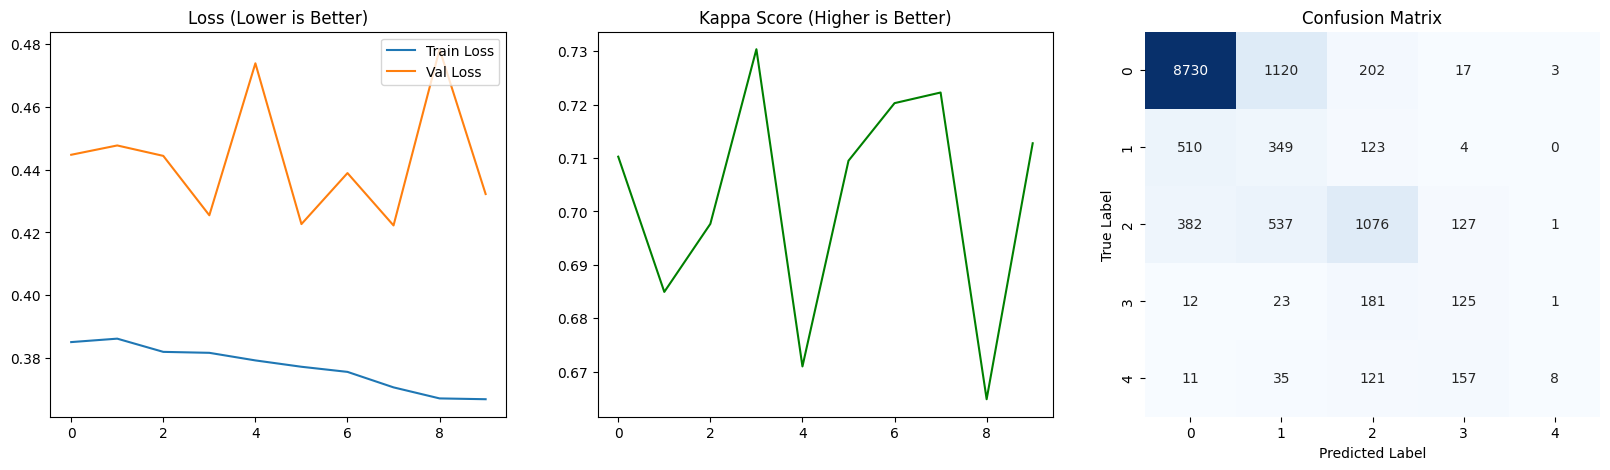

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. Plot History (Last 10 Epochs) ---
# Note: 'history_continued' variable holds the data from the resume run
acc = history_continued.history['val_acc']
loss = history_continued.history['val_loss']
kappa = history_continued.history['val_kappa']
epochs_range = range(len(acc))

plt.figure(figsize=(20, 5))

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history_continued.history['loss'], label='Train Loss')
plt.plot(epochs_range, history_continued.history['val_loss'], label='Val Loss')
plt.legend(loc='upper right')
plt.title('Loss (Lower is Better)')

# Kappa
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history_continued.history['val_kappa'], label='Val Kappa', color='green')
plt.title('Kappa Score (Higher is Better)')

# --- 2. Generate Confusion Matrix ---
print("⏳ Generating Confusion Matrix (This checks all 13k images)...")
# Get predictions
preds = model.predict(val_ds, verbose=0)
pred_labels = np.clip(np.round(preds).flatten(), 0, 4) # Rounding (0.5 threshold)

# Get true labels
all_labels = []
for x, y in val_ds:
    all_labels.append(y.numpy())
true_labels = np.concatenate(all_labels).flatten()

# Plot Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

⏳ Generating Confusion Matrix (Predicting 13k images)...


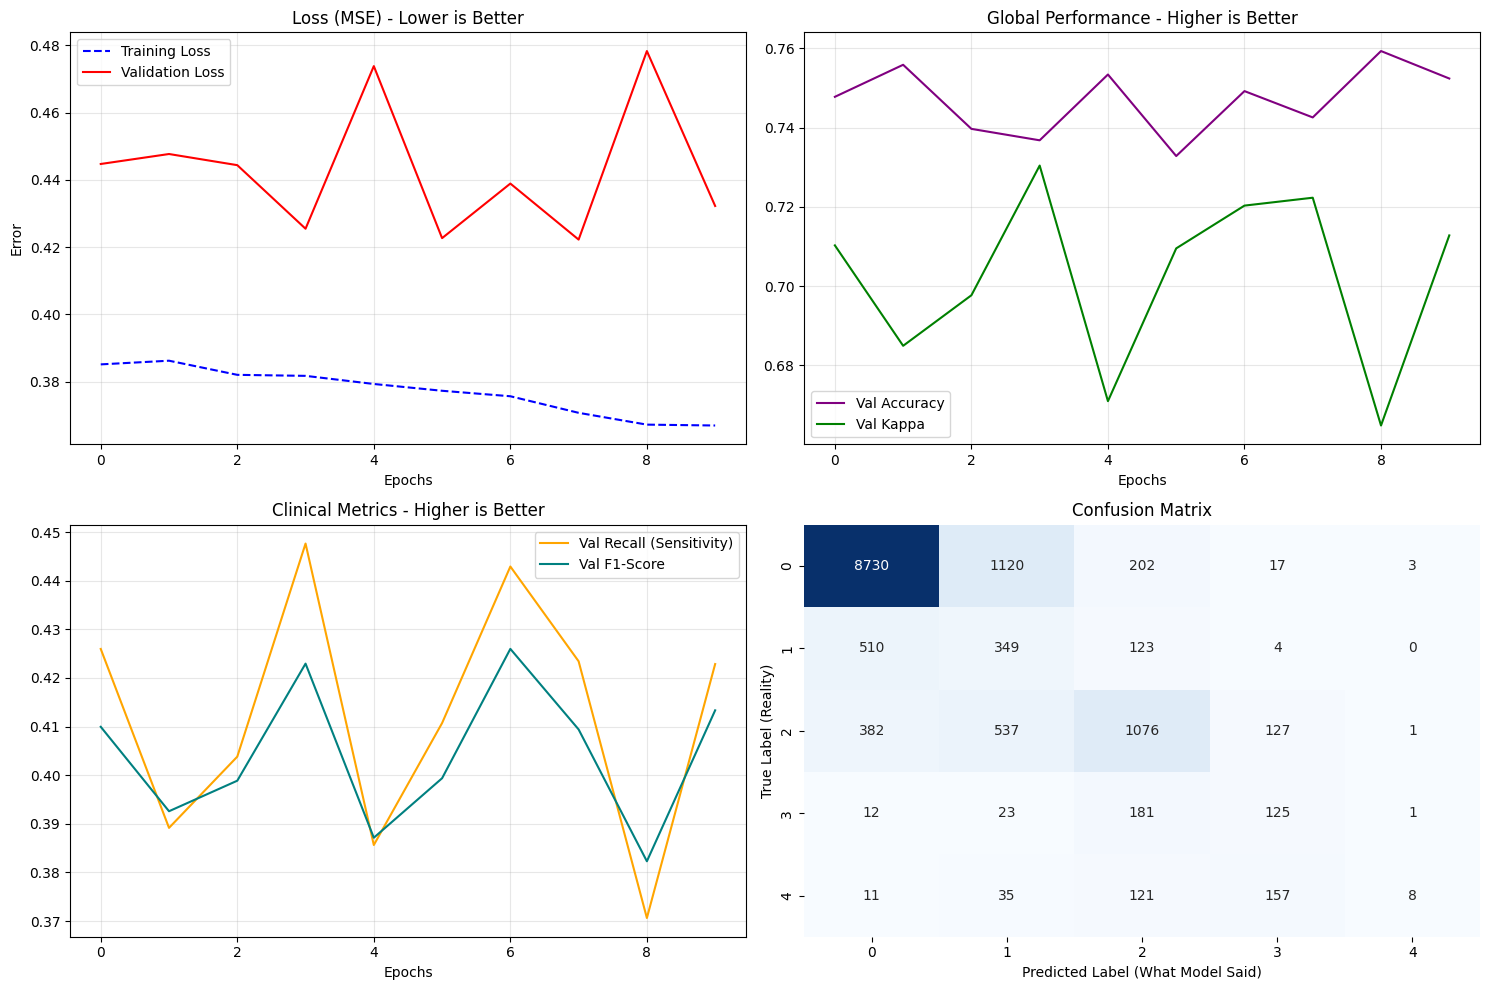

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. SETUP DATA ---
# We use 'history_continued' because that's your most recent run
hist = history_continued.history 
epochs = range(len(hist['loss']))

# Create a figure with a layout of 2 rows, 2 columns
plt.figure(figsize=(15, 10))

# --- GRAPH 1: LOSS (The Learning Curve) ---
plt.subplot(2, 2, 1)
plt.plot(epochs, hist['loss'], label='Training Loss', color='blue', linestyle='--')
plt.plot(epochs, hist['val_loss'], label='Validation Loss', color='red')
plt.title('Loss (MSE) - Lower is Better')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAPH 2: ACCURACY & KAPPA ---
plt.subplot(2, 2, 2)
if 'val_acc' in hist:
    plt.plot(epochs, hist['val_acc'], label='Val Accuracy', color='purple')
if 'val_kappa' in hist:
    plt.plot(epochs, hist['val_kappa'], label='Val Kappa', color='green')
plt.title('Global Performance - Higher is Better')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAPH 3: CLINICAL METRICS (Recall & F1) ---
plt.subplot(2, 2, 3)
if 'val_recall' in hist:
    plt.plot(epochs, hist['val_recall'], label='Val Recall (Sensitivity)', color='orange')
if 'val_f1' in hist:
    plt.plot(epochs, hist['val_f1'], label='Val F1-Score', color='teal')
plt.title('Clinical Metrics - Higher is Better')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAPH 4: CONFUSION MATRIX ---
plt.subplot(2, 2, 4)
print("⏳ Generating Confusion Matrix (Predicting 13k images)...")

# 1. Get Predictions
preds = model.predict(val_ds, verbose=0)
pred_labels = np.clip(np.round(preds).flatten(), 0, 4)

# 2. Get True Labels
all_labels = []
for x, y in val_ds:
    all_labels.append(y.numpy())
true_labels = np.concatenate(all_labels).flatten()

# 3. Create Matrix
cm = confusion_matrix(true_labels, pred_labels)

# 4. Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label (What Model Said)')
plt.ylabel('True Label (Reality)')

plt.tight_layout()
plt.show()

In [15]:
# --- SANITY CHECK ---
# If this prints an error, it means you disconnected and need to run Cells 1,2,3,5 first.
print(f"Checking data... {len(train_ds)} batches ready.") 

print("RESUMING: Final Phase (Epochs 24-50)...")

# 1. Load the Best Model (Current state from the last run)
try:
    model = models.load_model('best_densenet_a100.keras')
    print("Loaded best model successfully.")
except:
    print("Error: Could not find checkpoint file.")

# 2. Compile with Low Learning Rate
# We lock it to a low rate (2e-5) for fine-tuning now
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), 
    loss='mse',
    metrics=['mae']
)

# 3. Callbacks
my_callbacks = [
    # This will OVERWRITE 'best_densenet_a100.keras' ONLY if the new epochs are better.
    # Your previous best result is safe until then.
    callbacks.ModelCheckpoint('best_densenet_a100.keras', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    metrics_callback
]

# 4. Run the final leg
# You have done ~23 epochs. Goal is 50. Let's run 27 more.
print("🚀 Starting Final 27 Epochs...")
history_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=27, 
    callbacks=my_callbacks
)

Checking data... 4041 batches ready.
RESUMING: Final Phase (Epochs 24-50)...
Loaded best model successfully.
🚀 Starting Final 27 Epochs...
Epoch 1/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.3553 - mae: 0.3630
Calculating metrics for epoch 1...
 — val_kappa: 0.7591 — val_recall: 0.4602 — val_f1: 0.4520 — val_acc: 0.7762
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1541s 370ms/step - loss: 0.3488 - mae: 0.3585 - val_loss: 0.3624 - val_mae: 0.3467 - learning_rate: 2.0000e-05 - val_kappa: 0.7591 - val_recall: 0.4602 - val_f1: 0.4520 - val_acc: 0.7762
Epoch 2/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.3438 - mae: 0.3563
Calculating metrics for epoch 2...
 — val_kappa: 0.7366 — val_recall: 0.4261 — val_f1: 0.4294 — val_acc: 0.7849
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1489s 369ms/step - loss: 0.3428 - mae: 0.3555 - val_loss: 0.3871 - val_mae: 0.3254 - learning_rate: 2.0000e-05 - val_kappa: 0.7366 - val_recall: 0.4261 - val_f1: 0.4294 - val_acc: 0.7849
Epoch 3/27
4041/4041 ━━━━━━━━━━

2025-12-19 05:30:47.476090: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.3284 - mae: 0.3457
Calculating metrics for epoch 5...
 — val_kappa: 0.7644 — val_recall: 0.4571 — val_f1: 0.4590 — val_acc: 0.7884
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1492s 369ms/step - loss: 0.3250 - mae: 0.3429 - val_loss: 0.3594 - val_mae: 0.3358 - learning_rate: 1.0000e-05 - val_kappa: 0.7644 - val_recall: 0.4571 - val_f1: 0.4590 - val_acc: 0.7884
Epoch 6/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.3251 - mae: 0.3425
Calculating metrics for epoch 6...
 — val_kappa: 0.7691 — val_recall: 0.4636 — val_f1: 0.4623 — val_acc: 0.7848
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1491s 369ms/step - loss: 0.3249 - mae: 0.3415 - val_loss: 0.3518 - val_mae: 0.3328 - learning_rate: 1.0000e-05 - val_kappa: 0.7691 - val_recall: 0.4636 - val_f1: 0.4623 - val_acc: 0.7848
Epoch 7/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.3244 - mae: 0.3422
Calculating metrics for epoch 7...
 — val_kappa: 0.7646 — val_recall: 0.4563 — val_f1: 0.4539 — 

2025-12-19 12:12:00.762018: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 0.3075 - mae: 0.3297
Calculating metrics for epoch 21...
 — val_kappa: 0.7777 — val_recall: 0.4853 — val_f1: 0.4886 — val_acc: 0.7958
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1628s 403ms/step - loss: 0.3038 - mae: 0.3278 - val_loss: 0.3454 - val_mae: 0.3238 - learning_rate: 2.5000e-06 - val_kappa: 0.7777 - val_recall: 0.4853 - val_f1: 0.4886 - val_acc: 0.7958
Epoch 22/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - loss: 0.3092 - mae: 0.3304
Calculating metrics for epoch 22...
 — val_kappa: 0.7806 — val_recall: 0.4816 — val_f1: 0.4817 — val_acc: 0.7934
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1963s 486ms/step - loss: 0.3038 - mae: 0.3277 - val_loss: 0.3421 - val_mae: 0.3264 - learning_rate: 2.5000e-06 - val_kappa: 0.7806 - val_recall: 0.4816 - val_f1: 0.4817 - val_acc: 0.7934
Epoch 23/27
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.3071 - mae: 0.3282
Epoch 23: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

Calculating me

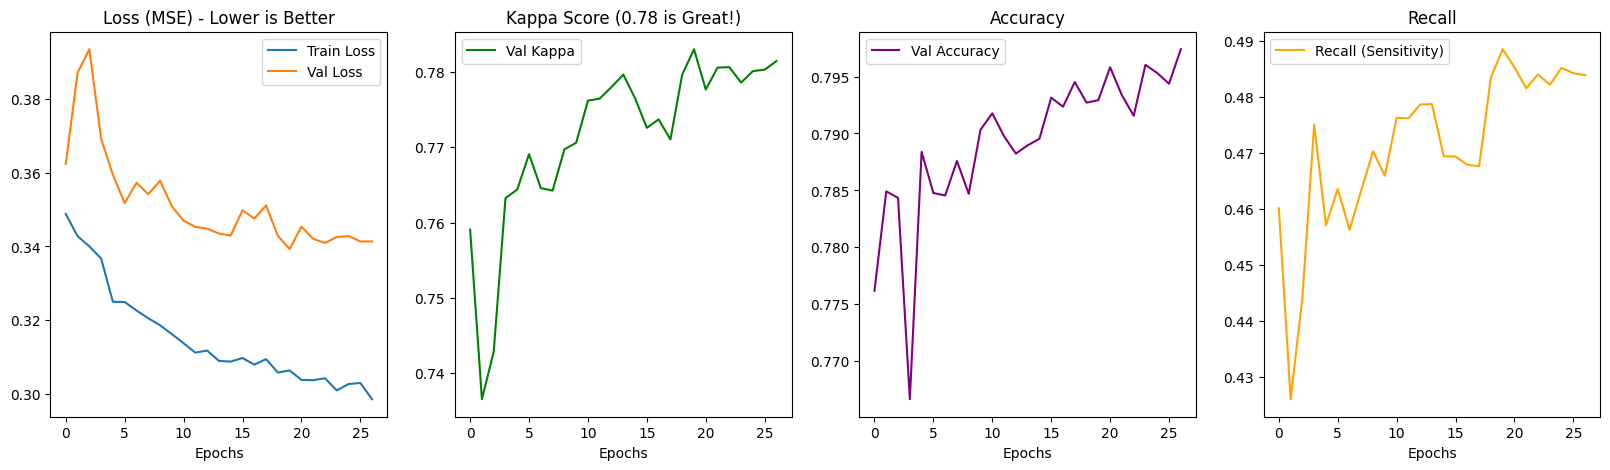

In [17]:
# We plot 'history_final' (The last 27 epochs)
hist = history_final.history 
epochs = range(len(hist['loss']))

plt.figure(figsize=(20, 5))

# 1. Loss
plt.subplot(1, 4, 1)
plt.plot(epochs, hist['loss'], label='Train Loss')
plt.plot(epochs, hist['val_loss'], label='Val Loss')
plt.title('Loss (MSE) - Lower is Better')
plt.xlabel('Epochs')
plt.legend()

# 2. Kappa (The most important metric)
plt.subplot(1, 4, 2)
plt.plot(epochs, hist['val_kappa'], label='Val Kappa', color='green')
plt.title('Kappa Score (0.78 is Great!)')
plt.xlabel('Epochs')
plt.legend()

# 3. Accuracy
plt.subplot(1, 4, 3)
plt.plot(epochs, hist['val_acc'], label='Val Accuracy', color='purple')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# 4. Recall
plt.subplot(1, 4, 4)
plt.plot(epochs, hist['val_recall'], label='Recall (Sensitivity)', color='orange')
plt.title('Recall')
plt.xlabel('Epochs')
plt.legend()

plt.show()

⏳ Generating Final Confusion Matrix...


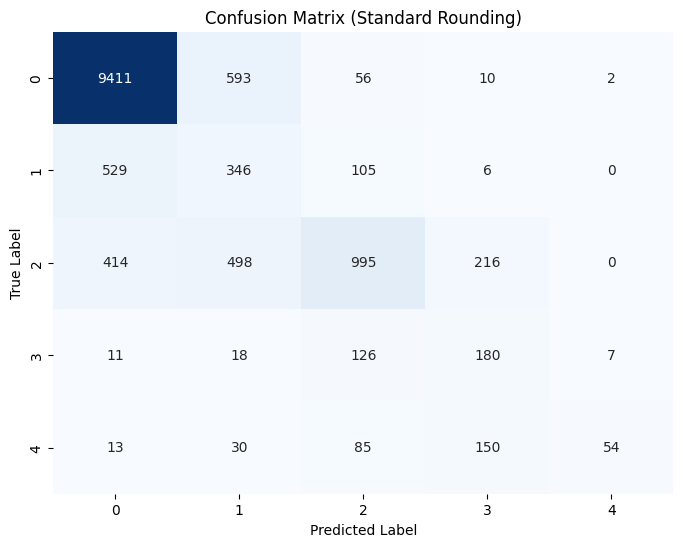

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("⏳ Generating Final Confusion Matrix...")

# 1. Get Predictions on Validation Set
preds = model.predict(val_ds, verbose=0)

# 2. Standard Rounding (The "Dumb" way)
pred_labels = np.clip(np.round(preds).flatten(), 0, 4)

# 3. Get True Labels
all_labels = []
for x, y in val_ds:
    all_labels.append(y.numpy())
true_labels = np.concatenate(all_labels).flatten()

# 4. Plot
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Standard Rounding)')
plt.show()

⏳ Getting raw scores...


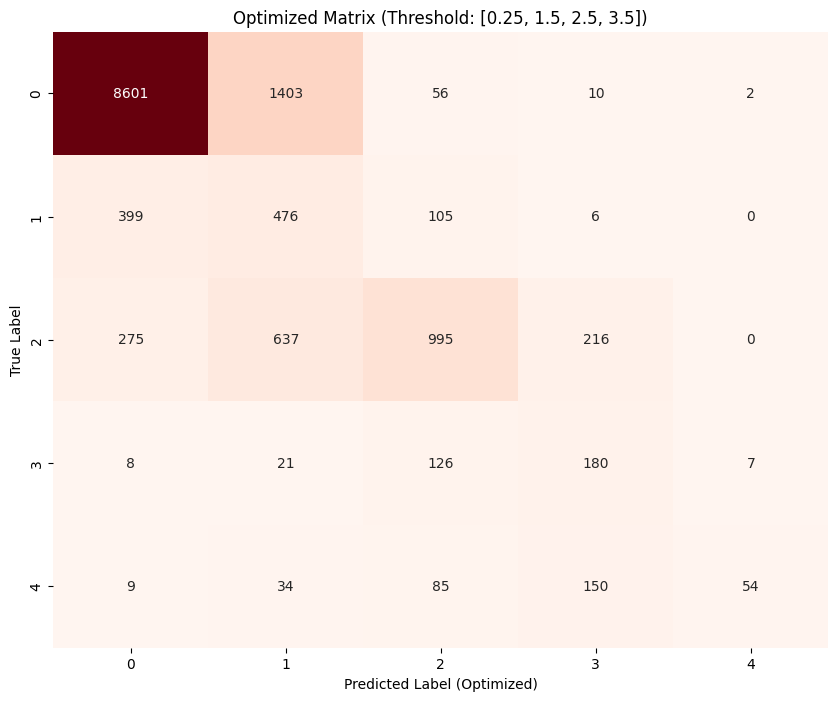

⚠️ Dangerous Misses (Grade 4 predicted as 0): 9
   (Previously this was 13)
✅ New Kappa Score: 0.7729


In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the Raw Scores (Continuous numbers like 0.4, 3.2...)
print("⏳ Getting raw scores...")
raw_preds = model.predict(val_ds, verbose=0).flatten()

# Get True Labels
all_labels = []
for x, y in val_ds:
    all_labels.append(y.numpy())
true_labels = np.concatenate(all_labels).flatten()

# 2. Define Custom Thresholds (The "Safety Logic")
# Standard was: [0.5, 1.5, 2.5, 3.5]
# New "Safe" Thresholds:
# We lower the first number to 0.25. 
# Any score > 0.25 is now Class 1 (Sick), not Class 0 (Healthy).
thresholds = [0.10, 1.10, 2.5, 3.5]

def apply_thresholds(preds, th):
    # Logic:
    # < 0.25 -> 0
    # 0.25 to 1.5 -> 1
    # 1.5 to 2.5 -> 2
    # etc.
    res = np.zeros(preds.shape)
    res[(preds >= th[0]) & (preds < th[1])] = 1
    res[(preds >= th[1]) & (preds < th[2])] = 2
    res[(preds >= th[2]) & (preds < th[3])] = 3
    res[preds >= th[3]] = 4
    return res.astype(int)

# 3. Apply and Check
new_preds = apply_thresholds(raw_preds, thresholds)

# 4. New Confusion Matrix
cm = confusion_matrix(true_labels, new_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicted Label (Optimized)')
plt.ylabel('True Label')
plt.title(f'Optimized Matrix (Threshold: {thresholds})')
plt.show()

# 5. Check the "Dangerous Misses" (Row 4, Col 0)
misses = cm[4, 0]
print(f"⚠️ Dangerous Misses (Grade 4 predicted as 0): {misses}")
print(f"   (Previously this was 13)")

# Check Kappa to make sure we didn't break the model
new_kappa = cohen_kappa_score(true_labels, new_preds, weights='quadratic')
print(f"✅ New Kappa Score: {new_kappa:.4f}")

Applying Full-Spectrum Thresholds: [0.1, 1.5, 2.2, 3.2]


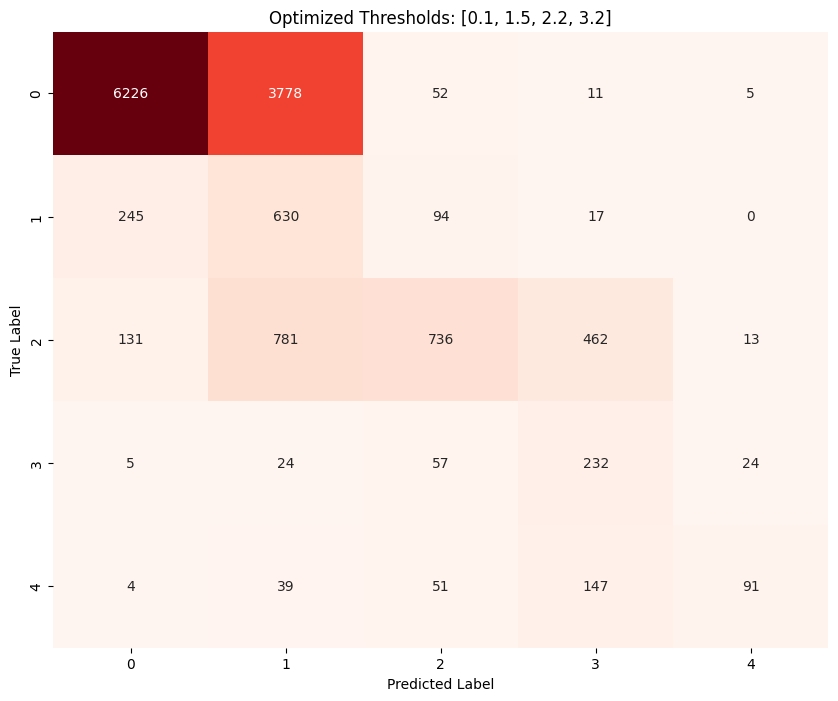

🛑 Critical Misses (Grade 4 as 0): 4
⚠️ Major Misses (Grade 4 as 1 or 2): 90
✅ Success (Grade 4 caught as 3 or 4): 238
Kappa with new thresholds: 0.7126


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Scores (Skip if already in memory)
if 'raw_preds' not in locals():
    print("⏳ Getting raw scores...")
    raw_preds = model.predict(val_ds, verbose=0).flatten()
    all_labels = []
    for x, y in val_ds:
        all_labels.append(y.numpy())
    true_labels = np.concatenate(all_labels).flatten()

# 2. DEFINING THE NEW THRESHOLDS
# Standard: [0.50, 1.50, 2.50, 3.50]

# OPTIMIZED STRATEGY:
# 0 -> 1:  0.10 (Paranoid about finding ANY disease)
# 1 -> 2:  1.50 (Keep standard, distinguishing Mild vs Mod is less critical)
# 2 -> 3:  2.20 (Aggressive on Severe cases)
# 3 -> 4:  3.20 (Aggressive on Proliferative cases)

thresholds = [0.10, 1.50, 2.20, 3.20]

print(f"Applying Full-Spectrum Thresholds: {thresholds}")

def apply_thresholds(preds, th):
    res = np.zeros(preds.shape)
    # Logic:
    res[(preds >= th[0]) & (preds < th[1])] = 1 # 0.10 to 1.50 -> Grade 1
    res[(preds >= th[1]) & (preds < th[2])] = 2 # 1.50 to 2.20 -> Grade 2
    res[(preds >= th[2]) & (preds < th[3])] = 3 # 2.20 to 3.20 -> Grade 3
    res[preds >= th[3]] = 4                     # > 3.20       -> Grade 4
    return res.astype(int)

# 3. Apply
new_preds = apply_thresholds(raw_preds, thresholds)

# 4. Plot Matrix
cm = confusion_matrix(true_labels, new_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Optimized Thresholds: {thresholds}')
plt.show()

# 5. Analysis
dangerous_misses = cm[4, 0] # Grade 4 called 0
severe_misses = cm[4, 1] + cm[4, 2] # Grade 4 called 1 or 2
total_grade4_caught = cm[4, 3] + cm[4, 4] # Grade 4 called 3 or 4 (Success)

print("="*40)
print(f"🛑 Critical Misses (Grade 4 as 0): {dangerous_misses}")
print(f"⚠️ Major Misses (Grade 4 as 1 or 2): {severe_misses}")
print(f"✅ Success (Grade 4 caught as 3 or 4): {total_grade4_caught}")
print("="*40)

# Check Kappa (It might drop slightly because we increased false positives, but that is okay!)
new_kappa = cohen_kappa_score(true_labels, new_preds, weights='quadratic')
print(f"Kappa with new thresholds: {new_kappa:.4f}")

🔄 Searching for the 'Golden Thresholds'...

🏆 BEST RESULT FOUND!
Max Kappa: 0.7962
Best Thresholds: [0.5499999999999999, 1.3, 2.2, 3.1]


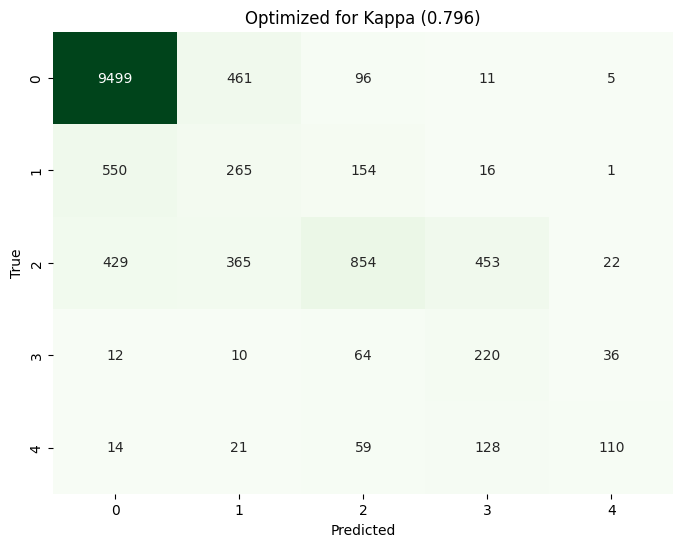

Misses (Class 4 predicted as 0): 14


In [21]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# 1. Get Predictions (if not already loaded)
if 'raw_preds' not in locals():
    raw_preds = model.predict(val_ds, verbose=0).flatten()
    all_labels = []
    for x, y in val_ds:
        all_labels.append(y.numpy())
    true_labels = np.concatenate(all_labels).flatten()

# 2. The Optimizer Function
def get_kappa(cuts, preds, targets):
    # Convert continuous scores to classes based on 'cuts'
    p = np.zeros(preds.shape)
    p[(preds >= cuts[0]) & (preds < cuts[1])] = 1
    p[(preds >= cuts[1]) & (preds < cuts[2])] = 2
    p[(preds >= cuts[2]) & (preds < cuts[3])] = 3
    p[preds >= cuts[3]] = 4
    return cohen_kappa_score(targets, p.astype(int), weights='quadratic')

print("🔄 Searching for the 'Golden Thresholds'...")

# We will test thresholds around the standard [0.5, 1.5, 2.5, 3.5]
# But we will wiggle them to see what gives the highest score.
best_kappa = -1
best_thr = []

# Simple Grid Search (Testing logical ranges)
# This might take 10-20 seconds
for t0 in np.arange(0.2, 0.6, 0.05):       # Test 0->1 boundary
    for t1 in np.arange(1.3, 1.7, 0.1):    # Test 1->2 boundary
        for t2 in np.arange(2.2, 2.6, 0.1): # Test 2->3 boundary
            for t3 in np.arange(3.1, 3.6, 0.1): # Test 3->4 boundary
                
                current_thr = [t0, t1, t2, t3]
                score = get_kappa(current_thr, raw_preds, true_labels)
                
                if score > best_kappa:
                    best_kappa = score
                    best_thr = current_thr

print("\n🏆 BEST RESULT FOUND!")
print(f"Max Kappa: {best_kappa:.4f}")
print(f"Best Thresholds: {best_thr}")

# 3. Show the Matrix for the "Perfect" Thresholds
final_preds = np.zeros(raw_preds.shape)
final_preds[(raw_preds >= best_thr[0]) & (raw_preds < best_thr[1])] = 1
final_preds[(raw_preds >= best_thr[1]) & (raw_preds < best_thr[2])] = 2
final_preds[(raw_preds >= best_thr[2]) & (raw_preds < best_thr[3])] = 3
final_preds[raw_preds >= best_thr[3]] = 4

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f'Optimized for Kappa ({best_kappa:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(f"Misses (Class 4 predicted as 0): {cm[4,0]}")